# Ising model simulated with the Metropolis algorithm

This notebook is part of the computational resources for the Statistical Physics course at École Polytechnique. To return to the main repository, follow this link: [https://github.com/cossio/StatPhysCompX](https://github.com/cossio/StatPhysCompX).

The 2-dimensional Ising model is defined by the energy function:

$$E(\mathbf{\sigma}) = - J\sum_{\langle i j \rangle} \sigma_i \sigma_j$$

where $\langle i j \rangle$ refers to connected pairs of sites in the square grid lattice, $\sigma_i = \pm 1$ are spins, and $J$ is a parameter controlling the strength of the interactions between neighboring spins. At inverse temperature $\beta$, this defines a Boltzmann probability distribution:

$$P(\mathbf{\sigma}) = \frac{1}{Z} \mathrm{e}^{-\beta E (\mathbf{\sigma})}$$

where

$$Z = \sum_{\mathbf{\sigma}} \mathrm{e}^{-\beta E(\mathbf{\sigma})}$$

is the partition function.

In the two-dimensional grid lattice, we assume we have a $L\times L$ plane grid, where each spin is connected to its four neighbors.
We assume periodic boundary conditions, so spin `(0,0)` is connected to spins `(0,L-1)` and `(L-1,0)`.

In the thermodynamic limit (large `L`), this model suffers a phase transition at the critical inverse temperature $J\beta \approx 0.44$, where it acquires a non-zero magnetization. The model was solved analytically by Onsager in 1944, who derived exact expressions for the magnetization, the free energy, the heat capacity, and the internal energy in the thermodynamic limits.

In this notebook, the system is simulated using the Metropolis algorithm. Note that we can absorb $\beta$ into $J$ by re-defining $J \rightarrow \beta J$, so that in what follows we only consider $J$ as a free parameter.

## References

- Newman, Mark EJ, and G. T. Barkema. "Monte Carlo Methods in Statistical Physics (1999)." New York: Oxford 475 (1999).
- Onsager, Lars. "Crystal statistics. I. A two-dimensional model with an order-disorder transition." Physical Review 65.3-4 (1944): 117.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

In [2]:
@njit
def _metropolis_sweep(sigma, J, L, n_steps):
    """Perform n_steps Metropolis single-spin-flip updates (in-place)."""
    for _ in range(n_steps):
        i = np.random.randint(0, L)
        j = np.random.randint(0, L)
        # Neighbor sum in {-1,+1} spin convention
        s_nb = (2*sigma[(i-1)%L, j] - 1 + 2*sigma[(i+1)%L, j] - 1 +
                2*sigma[i, (j-1)%L] - 1 + 2*sigma[i, (j+1)%L] - 1)
        s = 2*sigma[i, j] - 1
        dE = 2.0 * J * s * s_nb
        if dE <= 0.0 or np.random.random() < np.exp(-dE):
            sigma[i, j] = 1 - sigma[i, j]


def metropolis(J, L, steps_between_frames, number_of_frames):
    """Run Metropolis simulation and return (final_config, magnetization_per_spin_trace)."""
    sigma = np.random.randint(0, 2, (L, L), dtype=np.int8)
    N = L * L
    mag = np.zeros(number_of_frames)
    mag[0] = (2.0 * np.sum(sigma) - N) / N
    for f in range(1, number_of_frames):
        _metropolis_sweep(sigma, J, L, steps_between_frames)
        mag[f] = (2.0 * np.sum(sigma) - N) / N
    return sigma.copy(), mag

In [3]:
# Warm up numba JIT (first call triggers compilation)
_ = metropolis(0.4, 8, 100, 10)

In [4]:
values_of_J = [0.1, 0.4, 0.43, 0.44]

simulations = {}
for J in values_of_J:
    print(f"Simulating J={J}...")
    snap, mag = metropolis(J, L=64, steps_between_frames=4000, number_of_frames=50_000)
    simulations[J] = {"snapshot": snap, "magnetization": mag}
    print(f"  done.")

Simulating J=0.1...
  done.
Simulating J=0.4...
  done.
Simulating J=0.43...
  done.
Simulating J=0.44...
  done.


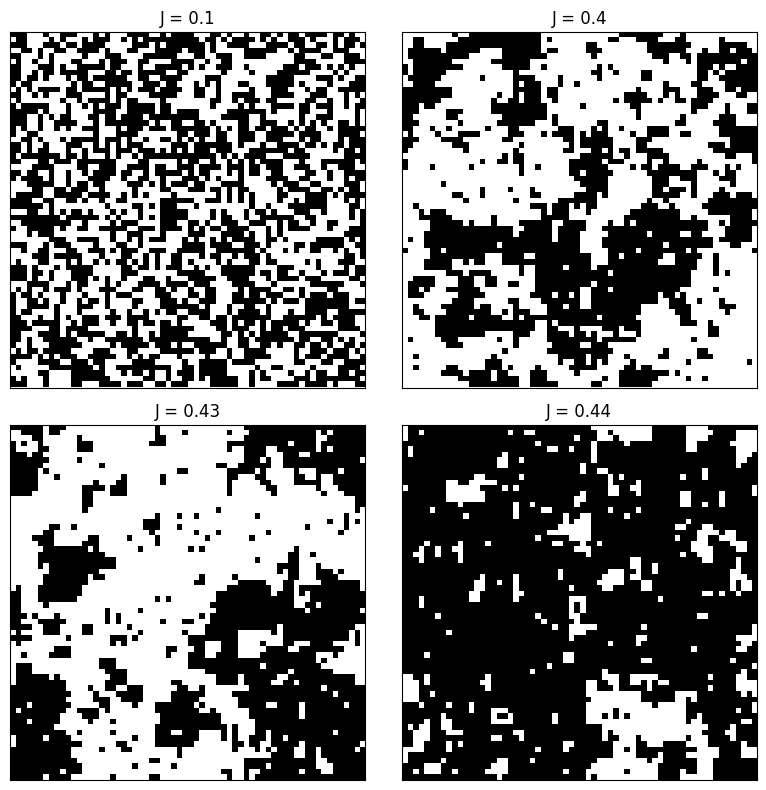

In [5]:
# Show some typical snapshots (final configuration)
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for ax, J in zip(axes.flat, values_of_J):
    ax.imshow(simulations[J]["snapshot"], cmap="gray_r", interpolation="nearest", vmin=0, vmax=1)
    ax.set_title(f"J = {J}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

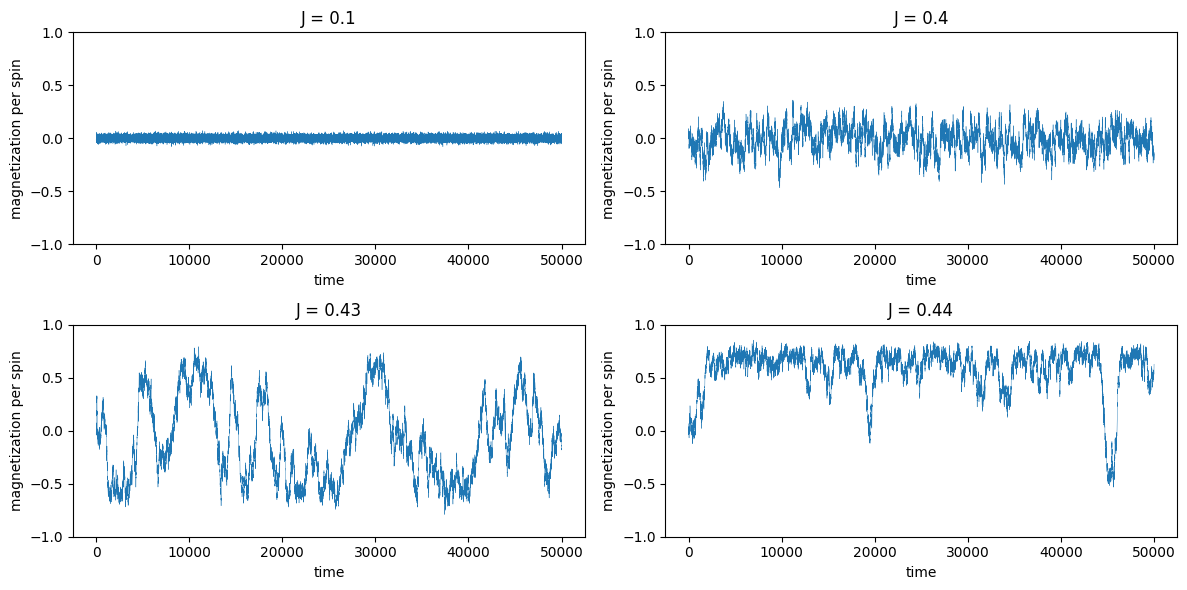

In [6]:
# Plot the magnetization per spin over time
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, J in zip(axes.flat, values_of_J):
    ax.plot(simulations[J]["magnetization"], linewidth=0.3)
    ax.set_title(f"J = {J}")
    ax.set_xlabel("time")
    ax.set_ylabel("magnetization per spin")
    ax.set_ylim(-1, 1)
plt.tight_layout()
plt.show()

The probability distribution over configurations of the Ising model we have defined above,

$$P(\mathbf{\sigma}) = \frac{1}{Z} \mathrm{e}^{-\beta E (\mathbf{\sigma})}$$

is symmetrical to a change of sign of all the spins:

$$P(\mathbf \sigma) = P(-\mathbf \sigma)$$

In particular, under $P(\sigma)$, each individual spin is as likely to be pointing up as it is to be pointing down.

At high temperatures, typical configurations sampled from $P(\sigma)$ are likely to have global magnetization (defined by $\frac{1}{N}\sum_i \sigma_i$) close to zero. However, as the temperature is decreased, we see that the system tends to get stuck for long periods of time into configurations where a global magnetization sign predominates over the opposite sign. In this case, the global magnetization is likely to be different from zero.

In [7]:
values_of_J_mag = [0.3, 0.4, 0.42, 0.43, 0.44, 0.45]

mag_histograms = {}
for J in values_of_J_mag:
    print(f"Simulating J={J}...")
    _, mag = metropolis(J, L=36, steps_between_frames=2000, number_of_frames=50_000)
    mag_histograms[J] = mag
    print(f"  done.")

Simulating J=0.3...
  done.
Simulating J=0.4...
  done.
Simulating J=0.42...
  done.
Simulating J=0.43...
  done.
Simulating J=0.44...
  done.
Simulating J=0.45...
  done.


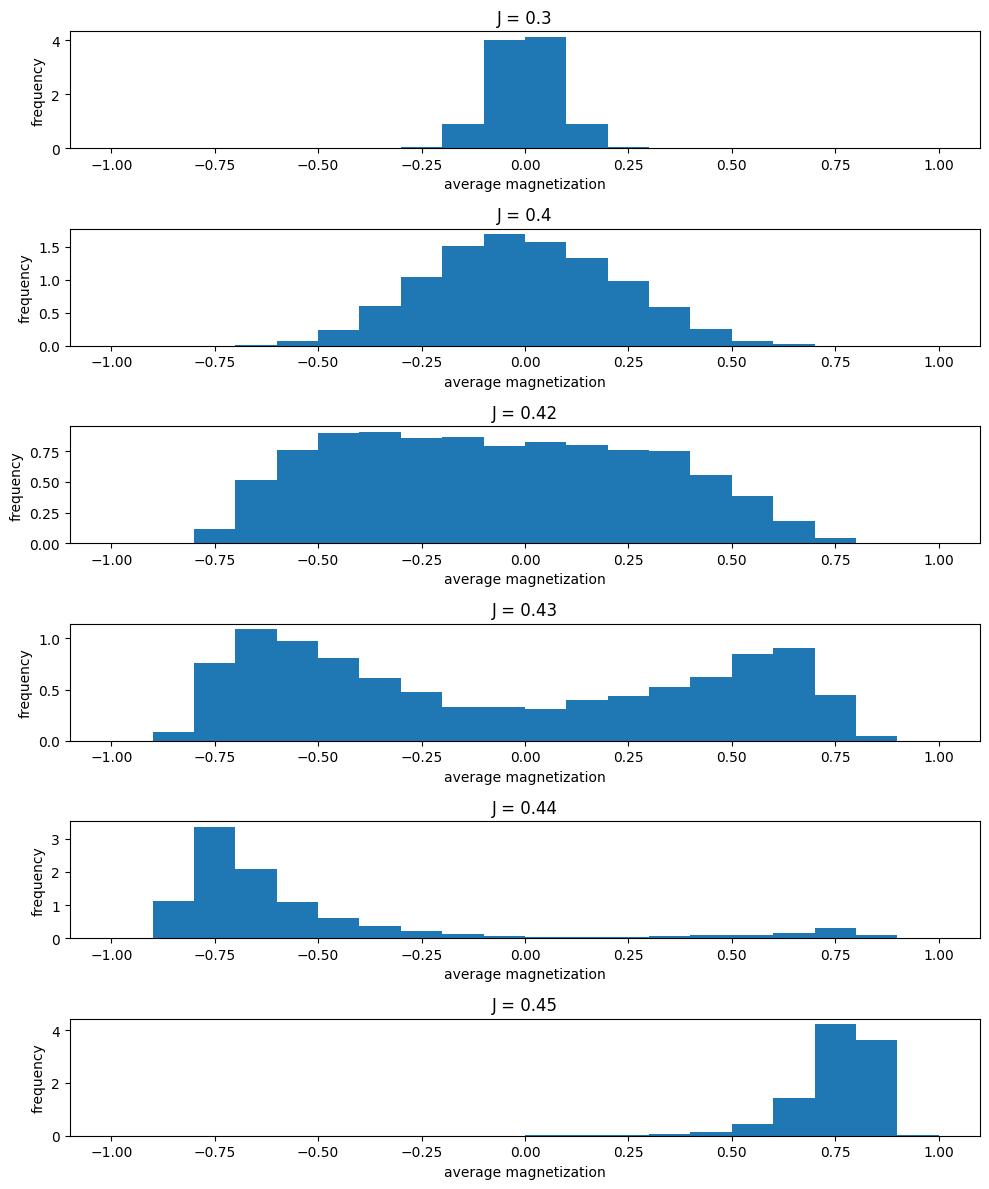

In [8]:
fig, axes = plt.subplots(len(values_of_J_mag), 1, figsize=(10, 2 * len(values_of_J_mag)))
for ax, J in zip(axes, values_of_J_mag):
    ax.hist(mag_histograms[J], bins=np.arange(-1, 1.05, 0.1), density=True)
    ax.set_title(f"J = {J}")
    ax.set_xlabel("average magnetization")
    ax.set_ylabel("frequency")
plt.tight_layout()
plt.show()

For low enough temperatures, the system gets stuck at one magnetization sign. It would take a very long time for the system to flip the magnetization sign.
Therefore the histogram of the average magnetization we see here (particularly for J=0.45) suffers this bias, and is not representative of the true equilibrium distribution of the model.

An alternative algorithm to simulate from the Ising model which overcomes this difficulty is the Wolff algorithm, which flips clusters of spins which share the same sign every unit step.

In his solution of the 2D Ising model, Onsager postulated the following analytical form for the magnetization as a function of $J$:

$$m = \max\{1 - \operatorname{csch}^{4}(2J), 0\}^{1/8}$$

This formula is only valid in the large $L$ limit.

We can check with our simulations how the agreement gets better as $L$ increases.

In [9]:
def onsager_magnetization(J):
    """Exact magnetization in the large L limit (Onsager)."""
    return np.maximum(1 - (1 / np.sinh(2 * J))**4, 0)**(1/8)

In [10]:
Js_onsager = np.arange(0.2, 0.725, 0.025)

results_onsager = {}
for L in [20, 48]:
    m_avg = []
    m_std = []
    for J in Js_onsager:
        print(f"  L={L}, J={J:.3f}...")
        _, mag = metropolis(J, L=L, steps_between_frames=100, number_of_frames=500_000)
        absmag = np.abs(mag)
        m_avg.append(np.mean(absmag))
        m_std.append(np.std(absmag))
    results_onsager[L] = {"avg": np.array(m_avg), "std": np.array(m_std)}

  L=20, J=0.200...
  L=20, J=0.225...
  L=20, J=0.250...
  L=20, J=0.275...
  L=20, J=0.300...
  L=20, J=0.325...
  L=20, J=0.350...
  L=20, J=0.375...
  L=20, J=0.400...
  L=20, J=0.425...
  L=20, J=0.450...
  L=20, J=0.475...
  L=20, J=0.500...
  L=20, J=0.525...
  L=20, J=0.550...
  L=20, J=0.575...
  L=20, J=0.600...
  L=20, J=0.625...
  L=20, J=0.650...
  L=20, J=0.675...
  L=20, J=0.700...
  L=48, J=0.200...
  L=48, J=0.225...
  L=48, J=0.250...
  L=48, J=0.275...
  L=48, J=0.300...
  L=48, J=0.325...
  L=48, J=0.350...
  L=48, J=0.375...
  L=48, J=0.400...
  L=48, J=0.425...
  L=48, J=0.450...
  L=48, J=0.475...
  L=48, J=0.500...
  L=48, J=0.525...
  L=48, J=0.550...
  L=48, J=0.575...
  L=48, J=0.600...
  L=48, J=0.625...
  L=48, J=0.650...
  L=48, J=0.675...
  L=48, J=0.700...


/tmp/ipykernel_1522046/3697966339.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.maximum(1 - (1 / np.sinh(2 * J))**4, 0)**(1/8)


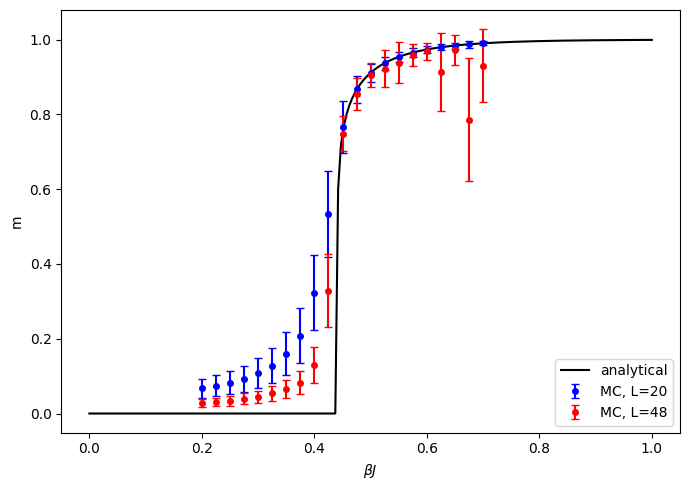

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
J_fine = np.linspace(0, 1, 200)
ax.plot(J_fine, onsager_magnetization(J_fine), "k-", label="analytical")
colors = {20: "blue", 48: "red"}
for L in [20, 48]:
    ax.errorbar(Js_onsager, results_onsager[L]["avg"],
                yerr=results_onsager[L]["std"] / 2,
                fmt="o", markersize=4, color=colors[L], label=f"MC, L={L}", capsize=3)
ax.set_xlabel(r"$\beta J$")
ax.set_ylabel("m")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()